# Creating and Training the CNN

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.layers import StringLookup

%matplotlib inline

IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 30
MIN_SAMPLES_PER_CLASS = 5

2026-04-17 13:37:05.227746: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 13:37:07.997322: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 13:37:20.838810: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Loading Annotations and Filtering Classes

In [2]:
with open('micronet_annotations.json', 'r') as f:
    annotations = json.load(f)

# we count the frequency of every class
class_counts = Counter(v['species_guess'] for v in annotations.values())

# get rid of classes that have less than the min samples
valid_classes = sorted([label for label, count in class_counts.items() if count >= MIN_SAMPLES_PER_CLASS])

print(f"Total Classes: {len(class_counts)}")
print(f"Valid Classes (>= {MIN_SAMPLES_PER_CLASS} images): {len(valid_classes)}")

# initialize encoder with valid classes
label_encoder = StringLookup(vocabulary=valid_classes, mask_token=None, num_oov_indices=0)
num_classes = len(valid_classes)

Total Classes: 2611
Valid Classes (>= 5 images): 409


2026-04-17 13:37:34.026734: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Making Dataframes

In [3]:
print(f"Current Jupyter Folder: {os.getcwd()}")
print("--- Creating DataFrames (Diagnostic Mode) ---")

def create_split_df(json_path):
    with open(json_path, 'r') as f:
        uuids = json.load(f)
        
    data = []
    missing_files = 0
    missing_annotation = 0
    filtered_out = 0
    
    for uid in uuids:
        img_path = f"micronet_images/{uid}.jpg"
        
        # does python see image?
        if not os.path.exists(img_path):
            missing_files += 1
            continue
            
        # id in master JSON?
        if uid not in annotations:
            missing_annotation += 1
            continue
            
        # species survive filter?
        label = annotations[uid]['species_guess']
        if label not in valid_classes:
            filtered_out += 1
            continue
            
        data.append({
            'path': img_path,
            'label': label
        })
        
    print(f"Stats for {json_path}:")
    print(f"  - Total IDs checked: {len(uuids)}")
    print(f"  - Skipped (Missing File): {missing_files}")
    print(f"  - Skipped (No Annotation): {missing_annotation}")
    print(f"  - Skipped (Rare Species): {filtered_out}")
    print(f"  - Successfully Added: {len(data)}")
    print("-" * 40)
    
    if len(data) == 0:
        return pd.DataFrame(columns=['path', 'label'])
        
    return pd.DataFrame(data)

train_df = create_split_df('train.json')
val_df = create_split_df('val.json')
test_df = create_split_df('test.json')

Current Jupyter Folder: /bigtemp/ngx6sg/MicroNetCNN
--- Creating DataFrames (Diagnostic Mode) ---
Stats for train.json:
  - Total IDs checked: 8047
  - Skipped (Missing File): 17
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 2588
  - Successfully Added: 5442
----------------------------------------
Stats for val.json:
  - Total IDs checked: 1006
  - Skipped (Missing File): 2
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 321
  - Successfully Added: 683
----------------------------------------
Stats for test.json:
  - Total IDs checked: 1006
  - Skipped (Missing File): 2
  - Skipped (No Annotation): 0
  - Skipped (Rare Species): 320
  - Successfully Added: 684
----------------------------------------


### Building Pipeline

In [4]:
def parse_function(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_image(image_string, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.convert_image_dtype(image, tf.float32) 
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    label_idx = label_encoder(label)
    return image, label_idx

def create_dataset(df, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['path'].values, df['label'].values))
    if shuffle:
        dataset = dataset.shuffle(len(df))
    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

### Checking if the images look right

2026-04-17 13:38:33.872989: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-04-17 13:38:34.234357: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


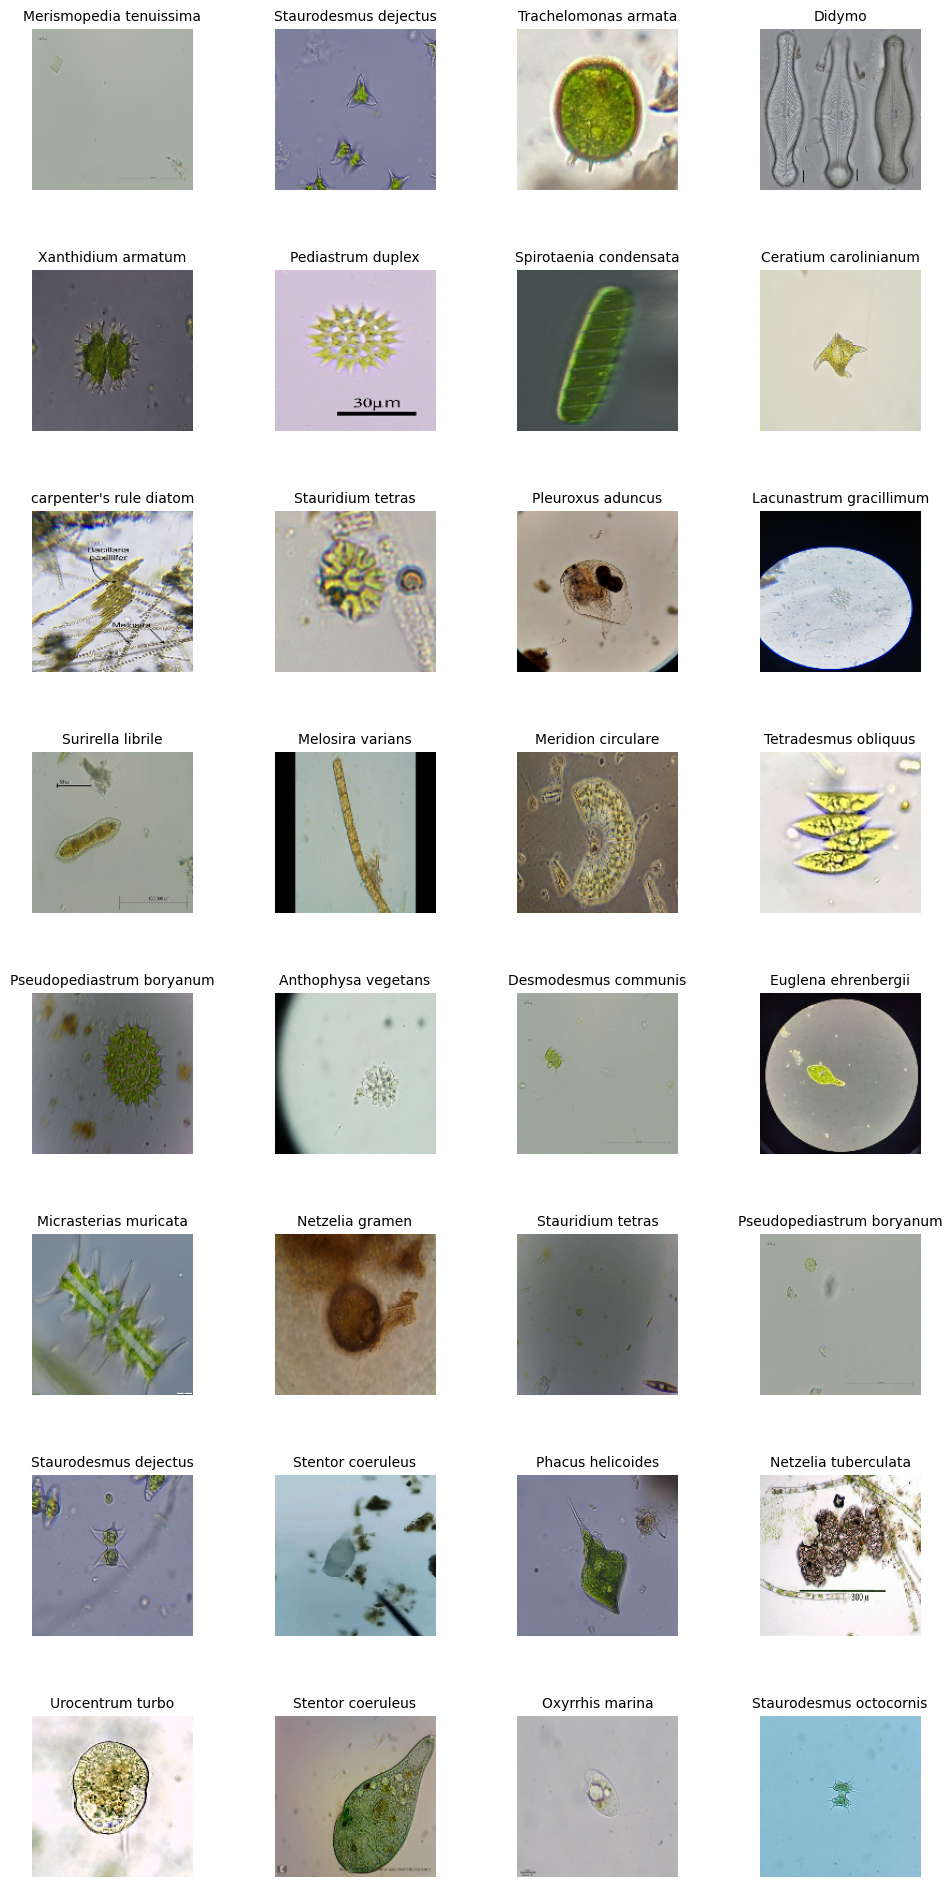

In [5]:
n_rows = 8
n_cols = 4
plt.figure(figsize=(n_cols * 3, n_rows * 3))

for images, labels in train_ds.take(1):
    for i in range(n_rows * n_cols):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i].numpy()) 
        plt.axis('off')
        label_idx = int(labels[i])
        plt.title(valid_classes[label_idx], fontsize=10)

plt.subplots_adjust(wspace=.2, hspace=.5)
plt.show()

### Making CNN

In [ ]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.5),             
    layers.Dense(num_classes, activation='softmax') 
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 409)            │       838,041 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,425,753 (93.18 MB)

 Trainable params: 838,041 (3.20 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Train Model

In [7]:
checkpoint_cb = callbacks.ModelCheckpoint('resnet_best_model.keras', save_best_only=True, monitor='val_accuracy')

early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb]
)

Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 72s 381ms/step - accuracy: 0.0259 - loss: 5.9367 - val_accuracy: 0.0337 - val_loss: 5.7283
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 56s 327ms/step - accuracy: 0.0344 - loss: 5.7144 - val_accuracy: 0.0307 - val_loss: 5.6873
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 56s 330ms/step - accuracy: 0.0340 - loss: 5.6750 - val_accuracy: 0.0307 - val_loss: 5.6677
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 55s 324ms/step - accuracy: 0.0349 - loss: 5.6463 - val_accuracy: 0.0337 - val_loss: 5.6567
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 55s 321ms/step - accuracy: 0.0360 - loss: 5.6252 - val_accuracy: 0.0337 - val_loss: 5.6500
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 57s 334ms/step - accuracy: 0.0391 - loss: 5.6007 - val_accuracy: 0.0366 - val_loss: 5.6390
Epoch 7/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 55s 324ms/step - accuracy: 0.0342 - loss: 5.5724 - val_accuracy: 0.0351 - val_loss: 5.6284
Epoch 8/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 59s 343ms/step - accuracy: 0.0384 - loss: 5

### Plotting Training on Graph

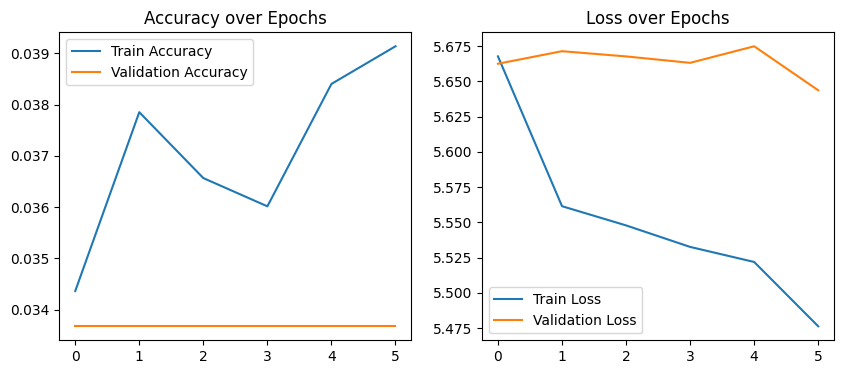

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()